In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Verify GPU availability for Kaggle session
device_name = tf.test.gpu_device_name()
if not device_name:
    print('Please activate GPU in Kaggle Settings > Accelerator')
else:
    print(f'Found GPU at: {device_name}')

2026-05-07 11:43:47.776375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778154227.974819      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778154228.032681      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778154228.501442      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778154228.501483      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778154228.501485      24 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0


I0000 00:00:1778154254.191422      24 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778154254.194921      24 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
train_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/train'
test_dir = '/kaggle/input/datasets/shamimulislamsunny/isic-2024-dataset/hair_removed/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
class_names = sorted(os.listdir(train_dir))

In [3]:
#File Path Extraction & Splitting (Creating Val Set)
def get_files_and_labels(path):
    file_paths = []
    labels = []
    for class_idx, class_name in enumerate(class_names):
        class_folder = os.path.join(path, class_name)
        for img_name in os.listdir(class_folder):
            file_paths.append(os.path.join(class_folder, img_name))
            labels.append(class_idx)
    return np.array(file_paths), np.array(labels)

# Get all images from the train folder
all_train_paths, all_train_labels = get_files_and_labels(train_dir)
test_file_paths, test_labels = get_files_and_labels(test_dir)

# Splitting Train folder into 80% Train and 20% Validation
X_train, X_val, y_train, y_val = train_test_split(
    all_train_paths, all_train_labels, test_size=0.2, random_state=42, stratify=all_train_labels
)

print(f"Final Training Images: {len(X_train)}")
print(f"Validation Images: {len(X_val)}")
print(f"Test Images: {len(test_file_paths)}")

Final Training Images: 257998
Validation Images: 64500
Test Images: 80212


In [4]:
#Class Weights (Handling Imbalance)
total = len(y_train)
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

class_weights = {
    0: (1 / neg) * (total / 2.0),
    1: (1 / pos) * (total / 2.0)
}
print(f"Weights -> Benign: {class_weights[0]:.2f}, Malignant: {class_weights[1]:.2f}")

Weights -> Benign: 0.50, Malignant: 82.06


In [5]:
#Pipeline & Preprocessing
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v3.preprocess_input(img)
    return img, label

def create_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle: ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_ds(X_train, y_train, shuffle=True)
val_ds = create_ds(X_val, y_val)
test_ds = create_ds(test_file_paths, test_labels)

I0000 00:00:1778154259.830606      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778154259.832078      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
#MobileNetV3
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')]
)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
#Training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "MobileNetV3_Balanced.h5", monitor='val_accuracy', save_best_only=True, mode='max'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint]
)

Epoch 1/20


I0000 00:00:1778154270.679383      69 service.cc:152] XLA service 0x7fa08c21cdc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778154270.679424      69 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778154270.679428      69 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778154272.289118      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 11:44:40.372079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:44:40.513762: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:44:40.848081: E external/local_xl

8061/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7665 - loss: 0.5041 - precision: 0.0206 - recall: 0.7592

2026-05-07 11:52:09.200043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:52:09.333964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:52:09.646671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:52:09.783554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 11:52:09.920352: E external/local_xla/xla/stream_

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7666 - loss: 0.5041 - precision: 0.0206 - recall: 0.7592

...

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 258s 32ms/step - accuracy: 0.9526 - loss: 0.1171 - precision: 0.1102 - recall: 0.9631 - val_accuracy: 0.9541 - val_loss: 0.1262 - val_precision: 0.1044 - val_recall: 0.8626
Epoch 9/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 264s 33ms/step - accuracy: 0.9582 - loss: 0.0989 - precision: 0.1242 - recall: 0.9705 - val_accuracy: 0.9512 - val_loss: 0.1366 - val_precision: 0.0992 - val_recall: 0.8677
Epoch 10/20
8062/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9587 - loss: 0.0966 - precision: 0.1260 - recall: 0.9694

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 262s 32ms/step - accuracy: 0.9587 - loss: 0.0966 - precision: 0.1260 - recall: 0.9694 - val_accuracy: 0.9642 - val_loss: 0.1035 - val_precision: 0.1285 - val_recall: 0.8448
Epoch 11/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 261s 32ms/step - accuracy: 0.9631 - loss: 0.1017 - precision: 0.1385 - recall: 0.9705 - val_accuracy: 0.9561 - val_loss: 0.1272 - val_precision: 0.1094 - val_recall: 0.8702
Epoch 12/20
8061/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9632 - loss: 0.0849 - precision: 0.1390 - recall: 0.9751

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 259s 32ms/step - accuracy: 0.9632 - loss: 0.0849 - precision: 0.1390 - recall: 0.9751 - val_accuracy: 0.9669 - val_loss: 0.1004 - val_precision: 0.1369 - val_recall: 0.8346
Epoch 13/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 257s 32ms/step - accuracy: 0.9674 - loss: 0.0816 - precision: 0.1542 - recall: 0.9788 - val_accuracy: 0.9663 - val_loss: 0.1012 - val_precision: 0.1348 - val_recall: 0.8372
Epoch 14/20
8061/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9692 - loss: 0.0780 - precision: 0.1622 - recall: 0.9800

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 259s 32ms/step - accuracy: 0.9692 - loss: 0.0780 - precision: 0.1622 - recall: 0.9800 - val_accuracy: 0.9731 - val_loss: 0.0883 - val_precision: 0.1631 - val_recall: 0.8270
Epoch 15/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 258s 32ms/step - accuracy: 0.9725 - loss: 0.0670 - precision: 0.1784 - recall: 0.9804 - val_accuracy: 0.9709 - val_loss: 0.0913 - val_precision: 0.1535 - val_recall: 0.8372
Epoch 16/20
8061/8063 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9702 - loss: 0.0743 - precision: 0.1672 - recall: 0.9810

8063/8063 ━━━━━━━━━━━━━━━━━━━━ 258s 32ms/step - accuracy: 0.9702 - loss: 0.0743 - precision: 0.1672 - recall: 0.9810 - val_accuracy: 0.9775 - val_loss: 0.0765 - val_precision: 0.1907 - val_recall: 0.8321
Epoch 17/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 260s 32ms/step - accuracy: 0.9726 - loss: 0.0723 - precision: 0.1784 - recall: 0.9791 - val_accuracy: 0.9742 - val_loss: 0.0881 - val_precision: 0.1707 - val_recall: 0.8397
Epoch 18/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 259s 32ms/step - accuracy: 0.9728 - loss: 0.0668 - precision: 0.1803 - recall: 0.9772 - val_accuracy: 0.9734 - val_loss: 0.0902 - val_precision: 0.1668 - val_recall: 0.8422
Epoch 19/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 256s 32ms/step - accuracy: 0.9736 - loss: 0.0679 - precision: 0.1844 - recall: 0.9780 - val_accuracy: 0.9744 - val_loss: 0.0882 - val_precision: 0.1729 - val_recall: 0.8473
Epoch 20/20
8063/8063 ━━━━━━━━━━━━━━━━━━━━ 256s 32ms/step - accuracy: 0.9730 - loss: 0.0682 - precision: 0.1815 - recall: 0.9788 - val_accuracy: 0.9

2507/2507 ━━━━━━━━━━━━━━━━━━━━ 206s 80ms/step

     MOBILENETV3 CLASSIFICATION REPORT
              precision    recall  f1-score   support

      benign       1.00      0.98      0.99     80133
   malignant       0.03      0.75      0.06        79

    accuracy                           0.98     80212
   macro avg       0.51      0.86      0.52     80212
weighted avg       1.00      0.98      0.99     80212



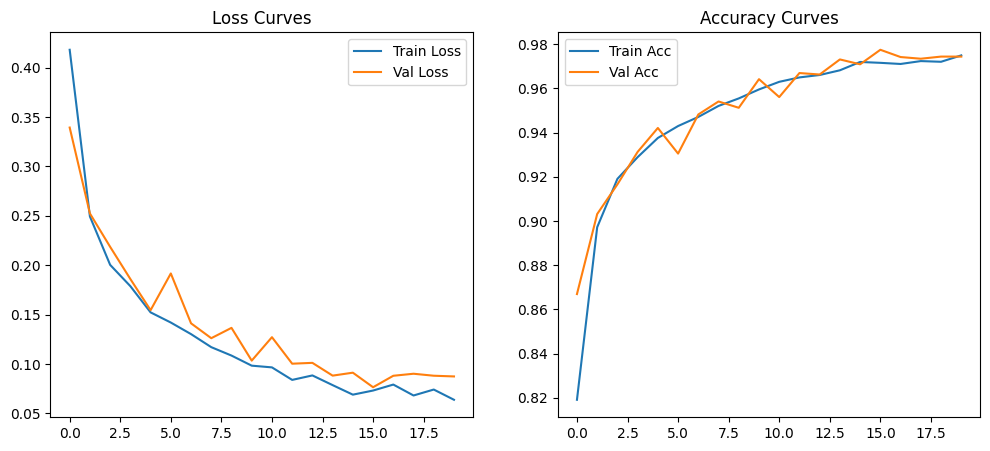

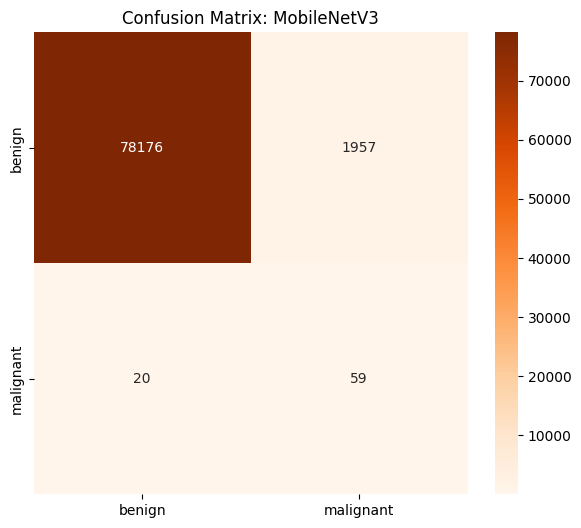


Final Test ROC-AUC: 0.9102


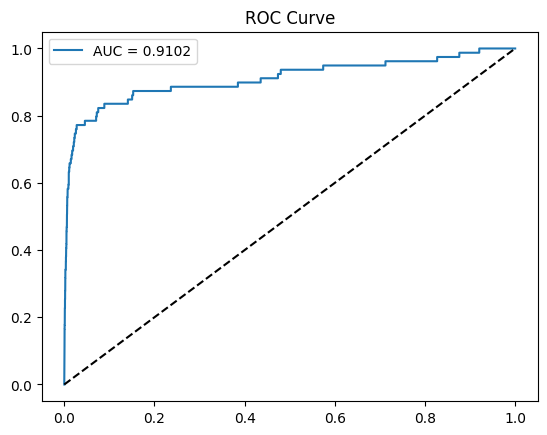

In [8]:
# 1. Prediction Generation
y_probs = model.predict(test_ds).flatten()
y_pred = (y_probs > 0.5).astype(int)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# 2. Classification Report
print("\n" + "="*40)
print("     MOBILENETV3 CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Training History Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: MobileNetV3')
plt.show()

# 5. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
print(f"\nFinal Test ROC-AUC: {auc(fpr, tpr):.4f}")
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.show()